# Module 1 — The AR(p) Model
## Topic 7: From Identification to Recursive Forecasting

**What this notebook covers — step by step**

| Step | Question | Tool |
|------|----------|------|
| 1 | What is the AR(p) model? | Math + intuition |
| 2 | Is my AR(p) stationary? | Stationarity condition |
| 3 | How do I choose $p$? | ACF/PACF + AIC/BIC |
| 4 | How do I estimate it? | OLS |
| 5 | How do I forecast 1-step ahead? | Conditional expectation |
| 6 | How do I forecast $h$-steps ahead? | Direct vs. iterative |
| 7 | Are my residuals OK? | Ljung-Box diagnostic |
| 8 | How good are my forecasts? | Recursive scheme + MAE/RMSE |

**Datasets**
- 📊 **US quarterly macro** (GDP growth, investment growth, inflation) — `statsmodels.macrodata` (1959–2009)
- 📈 **SP500 daily returns** (1981–1991) — `Ecdat/SP500`
- 📈 **DAX daily returns** (1991–1998) — `EuStockMarkets`
- 🌐 **Canadian macro** (T-bill rate, GDP, inflation) — `Ecdat/Tbrate` (1950–1996)

> In your own environment, replace the data-loading cells with `yfinance.download()` for equities and `fredapi.Fred().get_series()` for macro — the model code is identical.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import requests, io, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2166ac','#d6604d','#4dac26','#f4a582','#762a83'
print("Imports OK")

Imports OK


In [2]:
# ── Dataset 1: US Quarterly Macro (GDP, Investment, Inflation) ───────────────
#    Equivalent to FRED series: GDPC1, GPDIC1, CPIAUCSL

macro_raw = sm.datasets.macrodata.load_pandas().data
macro_raw['period'] = macro_raw.apply(
    lambda r: pd.Period(year=int(r.year), quarter=int(r.quarter), freq='Q'), axis=1)
macro = macro_raw.set_index('period')

# Transform to stationary growth rates (as required by seminar)
macro['gdp_growth']  = np.log(macro['realgdp']).diff()  * 100
macro['inv_growth']  = np.log(macro['realinv']).diff()  * 100
macro['cons_growth'] = np.log(macro['realcons']).diff() * 100
macro['infl']        = macro['infl']   # already in % (annualised)

print("US Macro:", macro.shape, "| 1959Q1 – 2009Q3")
macro[['gdp_growth','inv_growth','infl']].dropna().tail(4)

US Macro: (203, 17) | 1959Q1 – 2009Q3


,gdp_growth,inv_growth,infl
period,,,
2008Q4,-1.380483,-6.916465,-8.79
2009Q1,-1.661198,-17.559820,0.94
2009Q2,-0.185125,-6.756147,3.37
2009Q3,0.686219,2.019724,3.56


In [3]:
# ── Dataset 2: SP500 Daily Returns ───────────────────────────────────────────
#    Equivalent to: yfinance.download('^GSPC')['Close'].pct_change()

sp500 = sm.datasets.get_rdataset('SP500', 'Ecdat').data
sp500.index = pd.bdate_range(start='1981-01-02', periods=len(sp500))
sp500.columns = ['ret']
sp500['ret_pct'] = sp500['ret'] * 100    # convert to %
print("SP500 daily returns:", sp500.shape, "| 1981-01-02 –", sp500.index[-1].date())
sp500.head(3)

SP500 daily returns: (2783, 2) | 1981-01-02 – 1991-09-03


,ret,ret_pct
1981-01-02,-0.011727,-1.17265
1981-01-05,0.002454,0.24544
1981-01-06,0.011052,1.10516


In [4]:
# ── Dataset 3: DAX Daily Prices → Returns ─────────────────────────────────────
#    Equivalent to: yfinance.download('^GDAXI')

r = requests.get('https://raw.githubusercontent.com/vincentarelbundock/Rdatasets'
                 '/master/csv/datasets/EuStockMarkets.csv', timeout=10)
eu = pd.read_csv(io.StringIO(r.text))
eu.index = pd.bdate_range(start='1991-01-02', periods=len(eu))
dax = eu[['DAX']].copy()
dax['ret_pct'] = np.log(dax['DAX']).diff() * 100    # log-return in %
print("DAX:", dax.shape, "| 1991-01-02 –", dax.index[-1].date())
dax.head(3)

DAX: (1860, 2) | 1991-01-02 – 1998-02-17


,DAX,ret_pct
1991-01-02,1628.75,NaN
1991-01-03,1613.63,-0.932655
1991-01-04,1606.51,-0.442218


In [5]:
# ── Dataset 4: Canadian Macro (T-bill, GDP, Inflation) ───────────────────────
#    Quarterly 1950Q1–1996Q4: r = tbill rate, y = log GDP, pi = inflation

tb_raw = sm.datasets.get_rdataset('Tbrate', 'Ecdat').data
tb_raw.index = pd.period_range(start='1950Q1', periods=len(tb_raw), freq='Q')
tb_raw.columns = ['tbill', 'log_gdp', 'inflation']
tb_raw['gdp_growth'] = tb_raw['log_gdp'].diff() * 100   # approx % quarterly
print("Canada Macro:", tb_raw.shape, "| 1950Q1 – 1996Q4")
tb_raw.tail(3)

Canada Macro: (188, 4) | 1950Q1 – 1996Q4


,tbill,log_gdp,inflation,gdp_growth
1996Q2,4.777,13.328877,2.22,0.3553
1996Q3,4.216,13.337101,1.40,0.8224
1996Q4,3.028,13.344239,1.81,0.7138


---
## Step 1 — What Is the AR(p) Model?

### The model equation

$$\boxed{y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t, \qquad \varepsilon_t \sim \text{WN}(0,\sigma^2)}$$

In compact lag-operator notation:

$$\phi(L)\,y_t = c + \varepsilon_t, \qquad \phi(L) = 1 - \phi_1 L - \phi_2 L^2 - \cdots - \phi_p L^p$$

**Reading it in plain English**: today's value $y_t$ is a weighted average of its own last $p$ values, plus a constant $c$, plus a random shock $\varepsilon_t$ that nobody could have predicted.

**Why this model for macroeconomic forecasting?**

| Feature | Why it matters |
|---------|---------------|
| **GDP growth today** depends on GDP growth last quarter | Business cycles have momentum — recessions and expansions persist |
| **Stock returns** show (weak) autocorrelation at short lags | Order-flow and information diffusion create short-run dependence |
| **No exogenous variables needed** | AR(p) is the benchmark — any fancier model must beat it |

### The AR(p) is just OLS
For a pure AR(p), there are no MA terms. Each observation is a linear regression of $y_t$ on its own lags — you can write it as:

$$\underbrace{y_t}_{T \times 1} = \underbrace{\mathbf{X}_t}_{T \times (p+1)} \underbrace{\boldsymbol{\phi}}_{(p+1) \times 1} + \underbrace{\boldsymbol{\varepsilon}}_{T \times 1}, \qquad \hat{\boldsymbol{\phi}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}$$

where the design matrix $\mathbf{X}_t = [1,\; y_{t-1},\; y_{t-2},\; \ldots,\; y_{t-p}]$.


In [6]:
# ── AR(p) as OLS: build the design matrix manually ───────────────────────────
#    This makes the math totally transparent

gdp = macro['gdp_growth'].dropna()
p   = 2    # AR(2) for now

# Build design matrix: [1, y_{t-1}, y_{t-2}]
Y = gdp.values[p:]                     # dependent variable (T - p observations)
X = np.column_stack([                  # explanatory variables
    np.ones(len(Y)),                   # constant c
    gdp.values[p-1:-1],                # y_{t-1}
    gdp.values[p-2:-2],                # y_{t-2}
])

print("OLS setup for AR(2) on GDP growth:")
print(f"  Y (dependent)   : shape {Y.shape}  <- y_t")
print(f"  X (regressors)  : shape {X.shape}  <- [1, y_{{t-1}}, y_{{t-2}}]")
print(f"  First 3 rows of X:")
print(pd.DataFrame(X[:3], columns=['const','y_{t-1}','y_{t-2}']).round(3).to_string(index=False))

# Compute OLS by hand: beta = (X'X)^-1 X'y
beta_ols = np.linalg.solve(X.T @ X, X.T @ Y)
resid    = Y - X @ beta_ols
sigma2   = np.sum(resid**2) / (len(Y) - p - 1)

print(f"\nOLS estimates (by hand):")
print(f"  c         = {beta_ols[0]:.4f}")
print(f"  phi_1     = {beta_ols[1]:.4f}")
print(f"  phi_2     = {beta_ols[2]:.4f}")
print(f"  sigma^2   = {sigma2:.4f}")

OLS setup for AR(2) on GDP growth:
  Y (dependent)   : shape (200,)  <- y_t
  X (regressors)  : shape (200, 3)  <- [1, y_{t-1}, y_{t-2}]
  First 3 rows of X:
 const  y_{t-1}  y_{t-2}
   1.0   -0.119    2.494
   1.0    0.349   -0.119
   1.0    2.219    0.349

OLS estimates (by hand):
  c         = 0.4410
  phi_1     = 0.2687
  phi_2     = 0.1594
  sigma^2   = 0.6744


In [7]:
# ── Verify with statsmodels AutoReg ──────────────────────────────────────────
fit = AutoReg(gdp, lags=2, old_names=False).fit()
print("statsmodels AutoReg — AR(2) on US GDP growth (1959Q2–2009Q3):")
print(fit.summary().tables[1])   # coefficient table only

# Show they match
print(f"\nManual OLS vs statsmodels (should be identical):")
for i, name in enumerate(['const','phi_1','phi_2']):
    print(f"  {name}: manual={beta_ols[i]:.6f}  | statsmodels={fit.params.iloc[i]:.6f}")

statsmodels AutoReg — AR(2) on US GDP growth (1959Q2–2009Q3):
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4410      0.085      5.163      0.000       0.274       0.608
gdp_growth.L1     0.2687      0.069      3.878      0.000       0.133       0.404
gdp_growth.L2     0.1594      0.069      2.315      0.021       0.024       0.294

Manual OLS vs statsmodels (should be identical):
  const: manual=0.440972  | statsmodels=0.440972
  phi_1: manual=0.268673  | statsmodels=0.268673
  phi_2: manual=0.159358  | statsmodels=0.159358


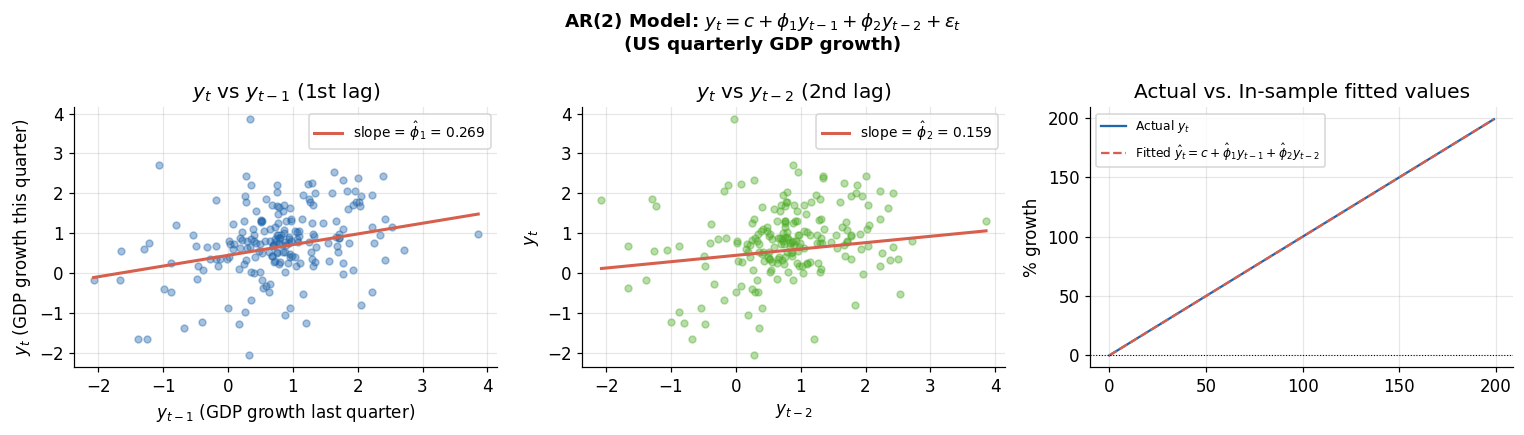

In [8]:
# ── Visualize: what AR(2) actually "sees" ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(r"AR(2) Model: $y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \varepsilon_t$"
             "\n(US quarterly GDP growth)", fontsize=12, fontweight='bold')

# Scatter: y_t vs y_{t-1}
axes[0].scatter(gdp.values[1:-1], gdp.values[2:], s=20, color=BLUE, alpha=0.4)
x_line = np.linspace(gdp.min(), gdp.max(), 100)
axes[0].plot(x_line, beta_ols[0] + beta_ols[1]*x_line, color=RED, lw=2,
             label=fr'slope = $\hat\phi_1$ = {beta_ols[1]:.3f}')
axes[0].set_title(r"$y_t$ vs $y_{t-1}$ (1st lag)")
axes[0].set_xlabel(r"$y_{t-1}$ (GDP growth last quarter)")
axes[0].set_ylabel(r"$y_t$ (GDP growth this quarter)")
axes[0].legend(fontsize=9)

# Scatter: y_t vs y_{t-2}
axes[1].scatter(gdp.values[:-2], gdp.values[2:], s=20, color=GREEN, alpha=0.4)
axes[1].plot(x_line, beta_ols[0] + beta_ols[2]*x_line, color=RED, lw=2,
             label=fr'slope = $\hat\phi_2$ = {beta_ols[2]:.3f}')
axes[1].set_title(r"$y_t$ vs $y_{t-2}$ (2nd lag)")
axes[1].set_xlabel(r"$y_{t-2}$")
axes[1].set_ylabel(r"$y_t$")
axes[1].legend(fontsize=9)

# Fitted vs actual
fitted = X @ beta_ols
axes[2].plot(range(len(Y)),      color=BLUE,  lw=1.5, label='Actual $y_t$')
axes[2].plot(range(len(fitted)), color=RED,   lw=1.5, ls='--',
             label=r'Fitted $\hat{y}_t = c + \hat\phi_1 y_{t-1} + \hat\phi_2 y_{t-2}$')
axes[2].axhline(0, color='black', lw=0.7, ls=':')
axes[2].set_title("Actual vs. In-sample fitted values")
axes[2].set_ylabel("% growth")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 2 — Stationarity: When Is an AR(p) Well-Behaved?

### The condition

An AR(p) process is **stationary** if and only if **all roots of the characteristic polynomial lie strictly outside the unit circle**.

The characteristic polynomial is formed by substituting $\lambda$ for $L$:

$$\phi(\lambda) = 1 - \phi_1\lambda - \phi_2\lambda^2 - \cdots - \phi_p\lambda^p = 0$$

The process is stationary $\iff |\lambda_i| > 1$ for all roots $\lambda_i$.

**For AR(1)**: the single root is $\lambda = 1/\phi_1$. Stationarity requires $|1/\phi_1| > 1 \iff |\phi_1| < 1$.

**For AR(2)**: the stationarity region is the triangle:
$$|\phi_2| < 1, \quad \phi_2 + \phi_1 < 1, \quad \phi_2 - \phi_1 < 1$$

### Why this matters in practice
If you fit an AR(p) to a non-stationary series (e.g., GDP *levels* instead of growth rates), the estimated $\phi$ will sum to approximately 1. Your forecasts will then explode or drift endlessly. The ADF test from Module 0 is your guard.

### What happens at the boundary
When $\phi_1 = 1$ exactly (random walk), the process has **infinite memory** — a shock from 10 years ago still has full impact today. For GDP growth rates (which are stationary), $\phi_1 \approx 0.3–0.5$ — shocks fade within a few quarters.


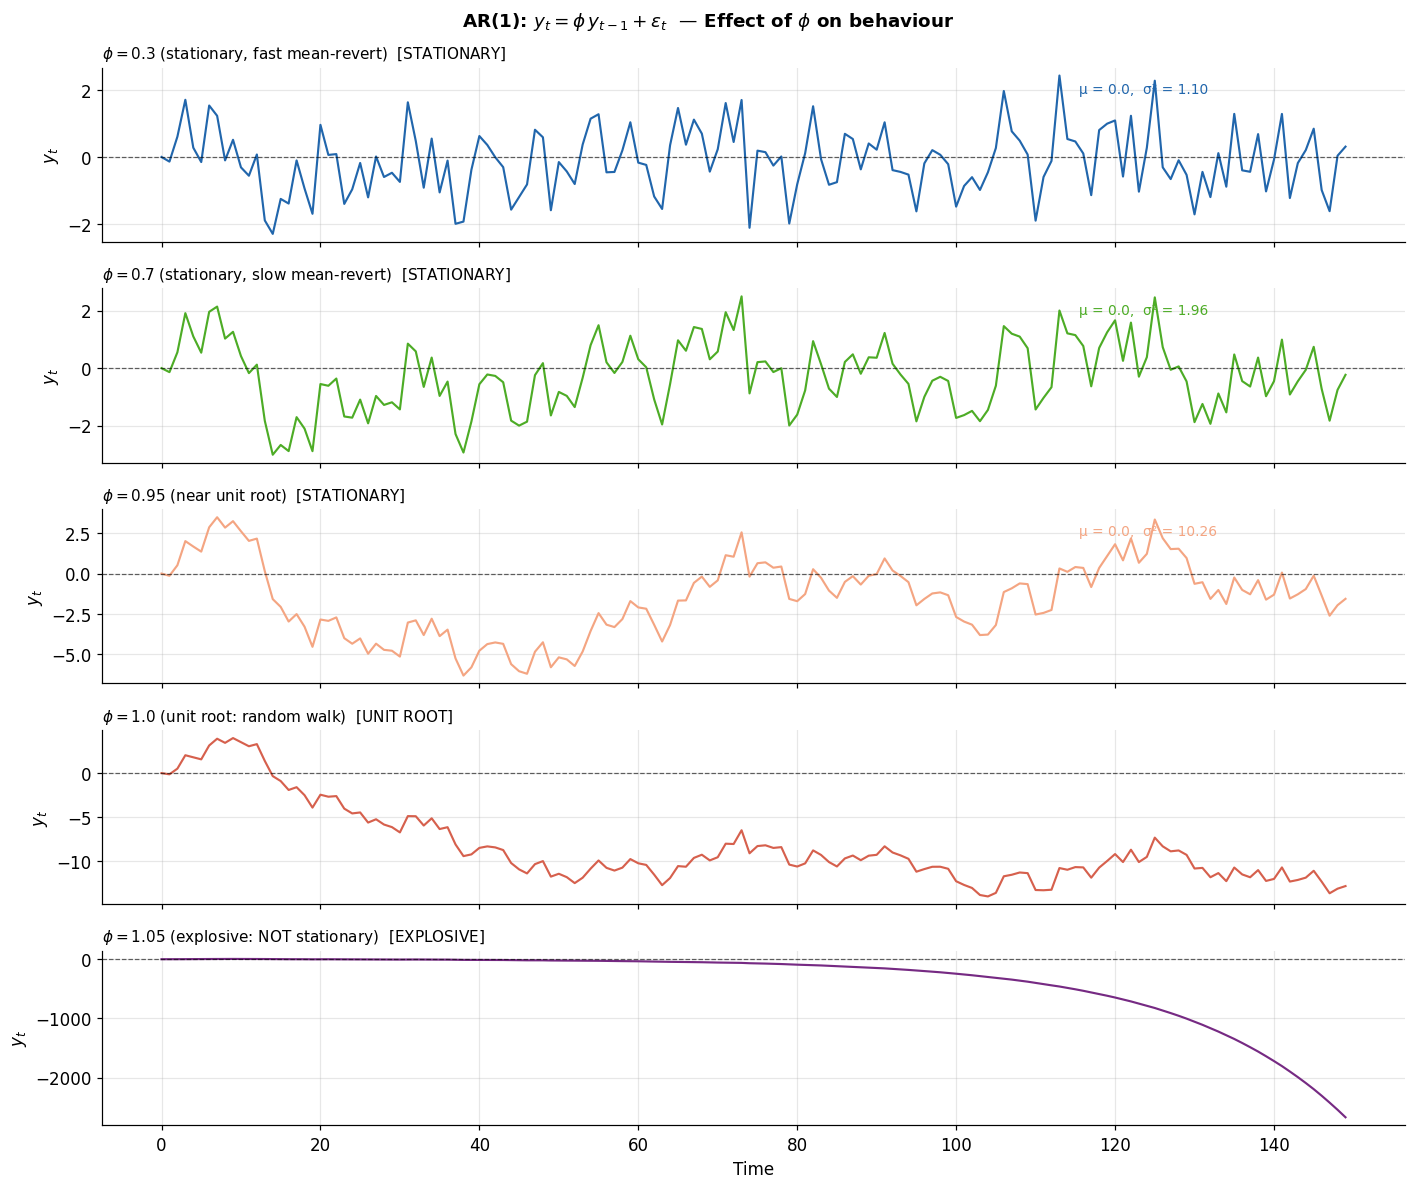

In [9]:
# ── Visualize stationarity: AR(1) for different phi values ───────────────────
np.random.seed(42)
T   = 150
eps = np.random.normal(0, 1, T)

phi_vals  = [0.3, 0.7, 0.95, 1.0, 1.05]
colors_   = [BLUE, GREEN, ORANGE, RED, PURPLE]
labels_   = [r'$\phi=0.3$ (stationary, fast mean-revert)',
             r'$\phi=0.7$ (stationary, slow mean-revert)',
             r'$\phi=0.95$ (near unit root)',
             r'$\phi=1.0$ (unit root: random walk)',
             r'$\phi=1.05$ (explosive: NOT stationary)']

fig, axes = plt.subplots(len(phi_vals), 1, figsize=(13, 11), sharex=True)
fig.suptitle(r"AR(1): $y_t = \phi\, y_{t-1} + \varepsilon_t$  — Effect of $\phi$ on behaviour",
             fontsize=12, fontweight='bold')

for ax, phi, color, label in zip(axes, phi_vals, colors_, labels_):
    y = np.zeros(T)
    for t in range(1, T):
        y[t] = phi * y[t-1] + eps[t]
    ax.plot(y, color=color, lw=1.4)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
    stationary = 'STATIONARY' if abs(phi) < 1 else ('UNIT ROOT' if phi == 1.0 else 'EXPLOSIVE')
    ax.set_title(f"{label}  [{stationary}]", fontsize=10, loc='left')
    ax.set_ylabel("$y_t$")
    if abs(phi) < 1:
        mean_str = f"μ = {0/(1-phi):.1f},  σ² = {1/(1-phi**2):.2f}"
        ax.annotate(mean_str, xy=(0.75, 0.85), xycoords='axes fraction',
                    fontsize=9, color=color)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

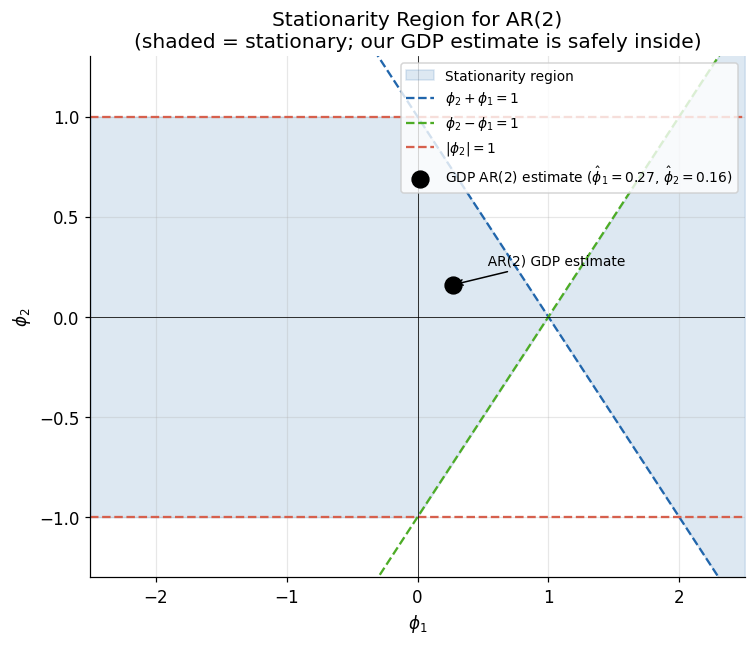

Our AR(2) GDP estimate: phi1=0.2687, phi2=0.1594
Stationarity checks:
  |phi2| < 1      :  0.1594 < 1  ->  True
  phi2 + phi1 < 1 :  0.4280 < 1  ->  True
  phi2 - phi1 < 1 :  -0.1093 < 1  ->  True


In [10]:
# ── Stationarity region for AR(2) ────────────────────────────────────────────
#    Triangle: |phi2| < 1,  phi2 + phi1 < 1,  phi2 - phi1 < 1

fig, ax = plt.subplots(figsize=(7, 6))

phi1_vals = np.linspace(-2.5, 2.5, 500)

# Boundaries of the stationarity triangle
ax.fill_between(phi1_vals,
                np.maximum(-1, phi1_vals - 1),   # phi2 > phi1 - 1
                np.minimum( 1, 1 - phi1_vals),   # phi2 < 1 - phi1
                color=BLUE, alpha=0.15, label='Stationarity region')

ax.plot(phi1_vals, 1 - phi1_vals,  color=BLUE, lw=1.5, ls='--', label=r'$\phi_2 + \phi_1 = 1$')
ax.plot(phi1_vals, phi1_vals - 1,  color=GREEN, lw=1.5, ls='--', label=r'$\phi_2 - \phi_1 = 1$')
ax.axhline(1,  color=RED,   lw=1.5, ls='--', label=r'$|\phi_2| = 1$')
ax.axhline(-1, color=RED,   lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)

# Plot our estimated GDP coefficients
phi1_est = beta_ols[1]
phi2_est = beta_ols[2]
ax.scatter([phi1_est], [phi2_est], s=120, color='black', zorder=5,
           label=fr'GDP AR(2) estimate ($\hat\phi_1={phi1_est:.2f}$, $\hat\phi_2={phi2_est:.2f}$)')
ax.annotate(fr'  AR(2) GDP estimate', xy=(phi1_est, phi2_est),
            xytext=(phi1_est+0.2, phi2_est+0.1), fontsize=9, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1))

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(r"$\phi_1$")
ax.set_ylabel(r"$\phi_2$")
ax.set_title("Stationarity Region for AR(2)\n(shaded = stationary; our GDP estimate is safely inside)")
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Our AR(2) GDP estimate: phi1={phi1_est:.4f}, phi2={phi2_est:.4f}")
print(f"Stationarity checks:")
print(f"  |phi2| < 1      :  {abs(phi2_est):.4f} < 1  ->  {abs(phi2_est)<1}")
print(f"  phi2 + phi1 < 1 :  {phi2_est+phi1_est:.4f} < 1  ->  {phi2_est+phi1_est<1}")
print(f"  phi2 - phi1 < 1 :  {phi2_est-phi1_est:.4f} < 1  ->  {phi2_est-phi1_est<1}")

---
## Step 3 — Choosing the Lag Order $p$: ACF/PACF + AIC/BIC

Two complementary approaches — use both and let them inform each other.

### Visual: ACF and PACF

From the identification table (Module 0):

- **AR(p)**: ACF tails off; PACF **cuts off sharply at lag $p$**
- Reading the PACF: the first lag after which the bar drops inside the $\pm 1.96/\sqrt{T}$ confidence band gives you $p$

### Formal: Information Criteria

$$\text{AIC}(p) = \log\hat\sigma^2_\varepsilon + \frac{2p}{T}, \qquad \text{BIC}(p) = \log\hat\sigma^2_\varepsilon + \frac{\log(T)\cdot p}{T}$$

Pick $p$ that minimizes the criterion. When AIC and BIC disagree: **BIC gives the more parsimonious model** (because $\log T > 2$ for $T > 8$). In small samples, AIC sometimes forecasts better out-of-sample.

**The seminar rule**: use both AIC and BIC as cross-checks. If they agree, you have a clear answer. If they disagree, estimate both models and compare their out-of-sample RMSE.


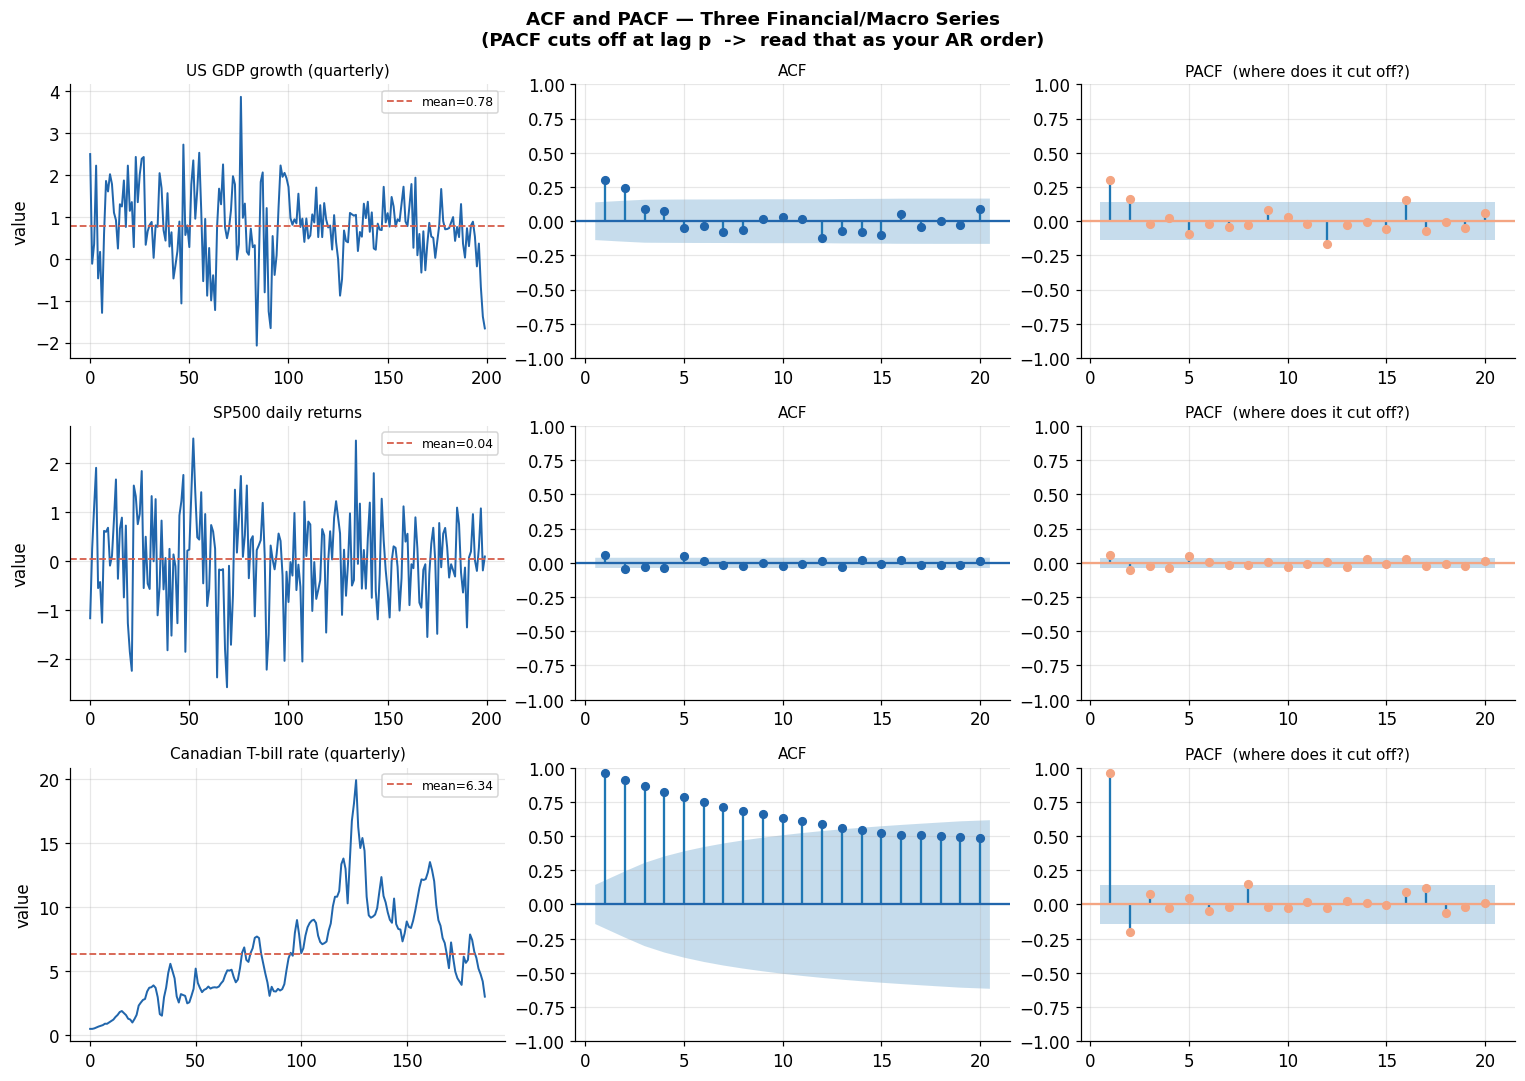

Reading guide:
  GDP growth   -> PACF significant at lags 1-2 -> try AR(1) or AR(2)
  SP500 returns-> PACF barely significant at lag 1 -> try AR(1) or even AR(0)
  T-bill rate  -> PACF large at lag 1, smaller at 2 -> try AR(1) or AR(2)


In [11]:
# ── ACF/PACF on three different series ───────────────────────────────────────
series_dict = {
    'US GDP growth (quarterly)':          macro['gdp_growth'].dropna(),
    'SP500 daily returns':                sp500['ret_pct'].dropna(),
    'Canadian T-bill rate (quarterly)':   tb_raw['tbill'].dropna(),
}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("ACF and PACF — Three Financial/Macro Series\n"
             "(PACF cuts off at lag p  ->  read that as your AR order)",
             fontsize=12, fontweight='bold')

for row, (title, series) in enumerate(series_dict.items()):
    # Time series plot
    axes[row, 0].plot(series.values[:200], color=BLUE, lw=1.3)
    axes[row, 0].axhline(series.mean(), color=RED, lw=1.2, ls='--',
                          label=f'mean={series.mean():.2f}')
    axes[row, 0].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel("value")
    axes[row, 0].legend(fontsize=8)

    # ACF
    plot_acf(series, ax=axes[row, 1], lags=20, color=BLUE, zero=False)
    axes[row, 1].set_title("ACF", fontsize=10)

    # PACF
    plot_pacf(series, ax=axes[row, 2], lags=20, method='ywm', color=ORANGE, zero=False)
    axes[row, 2].set_title("PACF  (where does it cut off?)", fontsize=10)

plt.tight_layout()
plt.show()

print("Reading guide:")
print("  GDP growth   -> PACF significant at lags 1-2 -> try AR(1) or AR(2)")
print("  SP500 returns-> PACF barely significant at lag 1 -> try AR(1) or even AR(0)")
print("  T-bill rate  -> PACF large at lag 1, smaller at 2 -> try AR(1) or AR(2)")

In [12]:
# ── AIC/BIC selection — systematic lag search ────────────────────────────────

def lag_selection_table(series, label, p_max=8):
    # Fit AR(1)..AR(p_max), return IC table and selections
    T = len(series.dropna())
    rows = []
    for p in range(1, p_max + 1):
        fit = AutoReg(series.dropna(), lags=p, old_names=False).fit()
        rows.append({'p': p, 'AIC': fit.aic, 'BIC': fit.bic,
                     'log_sigma2': np.log(fit.sigma2), 'nparams': p+1})
    ic = pd.DataFrame(rows).set_index('p')
    p_aic = ic['AIC'].idxmin()
    p_bic = ic['BIC'].idxmin()
    print(f"\n{'─'*52}")
    print(f"Lag selection: {label}  (T={T}, log(T)={np.log(T):.2f})")
    print(ic[['AIC','BIC']].round(3).to_string())
    print(f"  -> AIC selects p = {p_aic}")
    print(f"  -> BIC selects p = {p_bic}")
    return ic, p_aic, p_bic

ic_gdp, p_aic_gdp, p_bic_gdp = lag_selection_table(
    macro['gdp_growth'], "US GDP growth")
ic_tb, p_aic_tb, p_bic_tb = lag_selection_table(
    tb_raw['tbill'], "Canadian T-bill rate")
ic_sp, p_aic_sp, p_bic_sp = lag_selection_table(
    sp500['ret_pct'], "SP500 daily returns")


────────────────────────────────────────────────────
Lag selection: US GDP growth  (T=202, log(T)=5.31)
       AIC      BIC
p                  
1  501.468  511.378
2  493.767  506.960
3  493.908  510.375
4  489.489  509.218
5  483.560  506.543
6  483.902  510.127
7  479.666  509.123
8  479.767  512.445
  -> AIC selects p = 7
  -> BIC selects p = 5

────────────────────────────────────────────────────
Lag selection: Canadian T-bill rate  (T=188, log(T)=5.24)
       AIC      BIC
p                  
1  509.840  519.533
2  495.858  508.761
3  493.086  509.188
4  492.978  512.268
5  492.559  515.025
6  491.850  517.482
7  492.091  520.877
8  484.750  516.680
  -> AIC selects p = 8
  -> BIC selects p = 2

────────────────────────────────────────────────────
Lag selection: SP500 daily returns  (T=2783, log(T)=7.93)
        AIC       BIC
p                    
1  8352.173  8369.965
2  8345.511  8369.233
3  8343.015  8372.666
4  8336.716  8372.295
5  8328.665  8370.171
6  8328.538  8375.971
7  

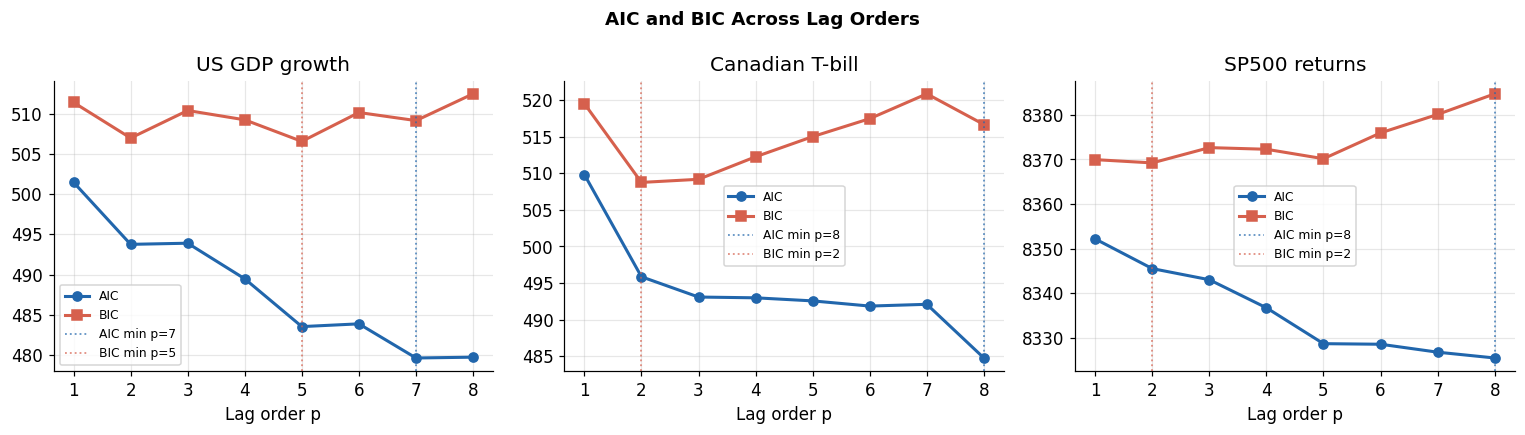

In [13]:
# ── Plot: AIC and BIC curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("AIC and BIC Across Lag Orders", fontsize=12, fontweight='bold')

for ax, (ic, p_a, p_b), title in zip(axes,
        [(ic_gdp, p_aic_gdp, p_bic_gdp),
         (ic_tb,  p_aic_tb,  p_bic_tb),
         (ic_sp,  p_aic_sp,  p_bic_sp)],
        ['US GDP growth', 'Canadian T-bill', 'SP500 returns']):

    ax.plot(ic.index, ic['AIC'], 'o-', color=BLUE, lw=2, ms=6, label='AIC')
    ax.plot(ic.index, ic['BIC'], 's-', color=RED,  lw=2, ms=6, label='BIC')
    ax.axvline(p_a, color=BLUE, lw=1.2, ls=':', alpha=0.7, label=f'AIC min p={p_a}')
    ax.axvline(p_b, color=RED,  lw=1.2, ls=':', alpha=0.7, label=f'BIC min p={p_b}')
    ax.set_title(title)
    ax.set_xlabel("Lag order p")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 4 — Estimating the AR(p)

Having selected $p$, estimation is straightforward OLS (for pure AR models — no MA terms). The `AutoReg` class from statsmodels handles this in one line, but let's read the output carefully.

**Key outputs to inspect:**
- **Coefficients** $\hat\phi_1, \ldots, \hat\phi_p$ — the persistence parameters
- **Standard errors** — how precisely are the coefficients estimated?
- **$\hat\sigma^2$** — the residual variance; related to 1-step-ahead RMSE
- **Log-likelihood, AIC, BIC** — for model comparison

**The unconditional mean** of a stationary AR(p):

$$E(y_t) = \mu = \frac{c}{1 - \phi_1 - \phi_2 - \cdots - \phi_p}$$

A useful check: if your estimated mean $\mu$ is far from the sample mean, something may be wrong.


In [14]:
# ── Full estimation output on three series ───────────────────────────────────

models = {
    'US GDP growth  AR(2)':   (macro['gdp_growth'].dropna(), 2),
    'Canadian T-bill AR(2)':  (tb_raw['tbill'].dropna(), 2),
    'SP500 returns AR(1)':    (sp500['ret_pct'].dropna(), 1),
}

fitted_models = {}
for name, (series, p) in models.items():
    fit = AutoReg(series, lags=p, old_names=False).fit()
    fitted_models[name] = fit

    # Compute unconditional mean
    phi_sum = sum(fit.params[1:])
    mu_hat  = fit.params.iloc[0] / (1 - phi_sum) if abs(1 - phi_sum) > 1e-6 else np.nan

    print(f"\n{'='*58}")
    print(f"Model: {name}")
    print(f"  c = {fit.params.iloc[0]:.4f},   sigma^2 = {fit.sigma2:.4f}")
    for i, (param, se) in enumerate(zip(fit.params[1:], fit.bse[1:]), 1):
        print(f"  phi_{i} = {param:.4f}  (se={se:.4f},  t={param/se:.2f})")
    print(f"  Unconditional mean mu = c/(1-sum(phi)) = {mu_hat:.4f}")
    print(f"  Sample mean                            = {series.mean():.4f}  <- should be close")
    print(f"  AIC={fit.aic:.2f},  BIC={fit.bic:.2f}")


Model: US GDP growth  AR(2)
  c = 0.4410,   sigma^2 = 0.6643
  phi_1 = 0.2687  (se=0.0693,  t=3.88)
  phi_2 = 0.1594  (se=0.0688,  t=2.32)
  Unconditional mean mu = c/(1-sum(phi)) = 0.7710
  Sample mean                            = 0.7758  <- should be close
  AIC=493.77,  BIC=506.96

Model: Canadian T-bill AR(2)
  c = 0.2656,   sigma^2 = 0.8066
  phi_1 = 1.2310  (se=0.0709,  t=17.36)
  phi_2 = -0.2713  (se=0.0705,  t=-3.85)
  Unconditional mean mu = c/(1-sum(phi)) = 6.5931
  Sample mean                            = 6.3420  <- should be close
  AIC=495.86,  BIC=508.76

Model: SP500 returns AR(1)
  c = 0.0400,   sigma^2 = 1.1761
  phi_1 = 0.0539  (se=0.0189,  t=2.85)
  Unconditional mean mu = c/(1-sum(phi)) = 0.0423
  Sample mean                            = 0.0418  <- should be close
  AIC=8352.17,  BIC=8369.97


---
## Step 5 — The 1-Step-Ahead Forecast

### Deriving the forecast from first principles

For the AR(2) model $y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \varepsilon_t$, the **1-step-ahead forecast** is simply the conditional expectation given all information up to time $T$:

$$\hat{y}_{T+1|T} = E(y_{T+1} \mid y_T, y_{T-1}, \ldots) = c + \phi_1 y_T + \phi_2 y_{T-1}$$

The $\varepsilon_{T+1}$ term drops out because $E(\varepsilon_{T+1} \mid \mathcal{I}_T) = 0$ — the future shock is zero in expectation.

### The 1-step forecast error

$$e_{T+1} = y_{T+1} - \hat{y}_{T+1|T} = \varepsilon_{T+1}$$

The forecast error **equals exactly the innovation** — the part of tomorrow that was genuinely unpredictable. The **Mean Squared Error** of the 1-step forecast is therefore:

$$\text{MSE}(\hat{y}_{T+1|T}) = E(e_{T+1}^2) = \sigma^2$$

**Key insight**: for 1-step-ahead forecasting, the lower bound on your RMSE is $\sigma$ (the standard deviation of the shocks). If your RMSE is much larger than $\hat\sigma$, you are losing information somewhere.


In [15]:
# ── 1-step forecast: formula materialized on GDP data ────────────────────────

gdp = macro['gdp_growth'].dropna()
fit = AutoReg(gdp, lags=2, old_names=False).fit()
c, phi1, phi2 = fit.params.values

# The last two observed values
yT   = gdp.iloc[-1]     # y_T   (most recent observation)
yT_1 = gdp.iloc[-2]     # y_{T-1}

# Apply the formula
y_hat_T1 = c + phi1 * yT + phi2 * yT_1

print("AR(2) for US GDP growth:")
print(f"  Estimated equation: y_t = {c:.4f} + {phi1:.4f}*y_{{t-1}} + {phi2:.4f}*y_{{t-2}}")
print(f"\n  Last two observed values:")
print(f"    y_T   = y_{gdp.index[-1]}  = {yT:.4f}%")
print(f"    y_{{T-1}} = y_{gdp.index[-2]}  = {yT_1:.4f}%")
print(f"\n  1-step forecast:")
print(f"    y_hat_{{T+1|T}} = {c:.4f} + {phi1:.4f}*{yT:.4f} + {phi2:.4f}*{yT_1:.4f}")
print(f"                 = {y_hat_T1:.4f}%")
print(f"\n  Interpretation: AR(2) predicts GDP growth of {y_hat_T1:.2f}% for the next quarter")
print(f"\n  sigma_hat = {np.sqrt(fit.sigma2):.4f}pp  <- minimum achievable RMSE (1-step)")

AR(2) for US GDP growth:
  Estimated equation: y_t = 0.4410 + 0.2687*y_{t-1} + 0.1594*y_{t-2}

  Last two observed values:
    y_T   = y_2009Q3  = 0.6862%
    y_{T-1} = y_2009Q2  = -0.1851%

  1-step forecast:
    y_hat_{T+1|T} = 0.4410 + 0.2687*0.6862 + 0.1594*-0.1851
                 = 0.5958%

  Interpretation: AR(2) predicts GDP growth of 0.60% for the next quarter

  sigma_hat = 0.8150pp  <- minimum achievable RMSE (1-step)


In [16]:
# ── 1-step forecast on SP500 returns ─────────────────────────────────────────
sp_ret = sp500['ret_pct'].dropna()
fit_sp = AutoReg(sp_ret, lags=1, old_names=False).fit()
c_sp, phi1_sp = fit_sp.params.values

yT_sp = sp_ret.iloc[-1]
y_hat_sp = c_sp + phi1_sp * yT_sp

print("AR(1) for SP500 daily returns:")
print(f"  y_t = {c_sp:.5f} + {phi1_sp:.5f} * y_{{t-1}}")
print(f"  Last return y_T = {yT_sp:.4f}%")
print(f"  1-step forecast y_hat_{{T+1|T}} = {y_hat_sp:.5f}%")
print(f"\n  Note: phi1 = {phi1_sp:.5f} is near zero -> ")
print(f"  The AR(1) forecast is nearly the unconditional mean ({c_sp/(1-phi1_sp):.5f}%)")
print(f"  This reflects the near-random-walk nature of daily stock returns.")
print(f"  sigma_hat = {np.sqrt(fit_sp.sigma2):.4f}pp  << much larger than the forecast itself")

AR(1) for SP500 daily returns:
  y_t = 0.03999 + 0.05392 * y_{t-1}
  Last return y_T = -0.2627%
  1-step forecast y_hat_{T+1|T} = 0.02582%

  Note: phi1 = 0.05392 is near zero -> 
  The AR(1) forecast is nearly the unconditional mean (0.04227%)
  This reflects the near-random-walk nature of daily stock returns.
  sigma_hat = 1.0845pp  << much larger than the forecast itself


---
## Step 6 — The $h$-Step-Ahead Forecast: Direct vs. Iterative

For horizons beyond $h=1$, you have two strategies. The seminar requires **both** for the AR(p) benchmark.

---

### (A) Direct forecast

Re-estimate a *separate* regression for each horizon $h$ — regress $y_{t+h}$ directly on the lags available at time $t$:

$$\hat{y}_{T+h|T}^{\text{direct}} = \hat{c}^{(h)} + \hat\phi_1^{(h)} y_T + \hat\phi_2^{(h)} y_{T-1} + \cdots + \hat\phi_p^{(h)} y_{T-p+1}$$

Each $h$ gets its **own estimated coefficients** $\hat\phi^{(h)}$. The model is allowed to learn a different relationship for each horizon.

**Pro**: more flexible, allows different dynamics at different horizons.  
**Con**: you need $h$ separate regressions; small samples can cause imprecision at long horizons.

---

### (B) Iterative (plug-in) forecast

Estimate **one** AR(p) model and iterate:

$$\hat{y}_{T+1|T} = c + \phi_1 y_T + \cdots + \phi_p y_{T-p+1}$$
$$\hat{y}_{T+2|T} = c + \phi_1 \hat{y}_{T+1|T} + \phi_2 y_T + \cdots$$
$$\hat{y}_{T+h|T} = c + \phi_1 \hat{y}_{T+h-1|T} + \cdots + \phi_p \hat{y}_{T+h-p|T}$$

**Pro**: uses all data efficiently, theoretically optimal if the AR(p) is the true model.  
**Con**: model misspecification at lag 1 compounds across $h$ — errors build on errors.

---

### Forecast uncertainty grows with $h$

For an AR(1) the MSE at horizon $h$ is:

$$\text{MSE}(\hat{y}_{T+h|T}) = \sigma^2 \left(1 + \phi_1^2 + \phi_1^4 + \cdots + \phi_1^{2(h-1)}\right) = \sigma^2 \frac{1 - \phi_1^{2h}}{1 - \phi_1^2}$$

As $h \to \infty$, MSE $\to \sigma^2 / (1-\phi_1^2) = \text{Var}(y_t)$ — the unconditional variance. Long-horizon forecasts carry **no more information** than the unconditional mean.


In [17]:
# ── Direct h-step forecast for AR(2) on GDP growth ──────────────────────────
#    Re-estimate a separate model for each h; seminar eq. (5)

gdp = macro['gdp_growth'].dropna()
p   = 2

def direct_forecast(series, p, h):
    # Direct h-step: regress y_{t+h} on [1, y_t, ..., y_{t-p+1}]
    y = series.values
    N = len(y)
    # Build: Y = y[p+h:],  X = [1, y[p+h-1-0], y[p+h-1-1], ..., y[p+h-p]]
    # i.e., for each t from p to N-h, regress y[t+h] on [1, y[t], ..., y[t-p+1]]
    Y = y[p + h - 1:]
    X = np.column_stack([np.ones(len(Y))] +
                        [y[p + h - 1 - j: len(y) - j] for j in range(p)])
    beta = np.linalg.solve(X.T @ X, X.T @ Y)
    # Forecast: plug in the last p values
    x_last = np.array([1] + [y[-(j+1)] for j in range(p)])
    return float(x_last @ beta), beta

print("AR(2) direct h-step forecasts — US GDP growth")
print(f"Last two values: y_T={gdp.iloc[-1]:.3f}%, y_{{T-1}}={gdp.iloc[-2]:.3f}%\n")
print(f"{'h':<6} {'Direct forecast':>18} {'Coefficients (c, phi1, phi2)':>35}")
print("─" * 62)
for h in [1, 2, 3, 4]:
    fc, beta = direct_forecast(gdp, p, h)
    print(f"h={h}    {fc:>14.4f}%     c={beta[0]:.4f}, φ1={beta[1]:.4f}, φ2={beta[2]:.4f}")

print("\nNote: each horizon has DIFFERENT coefficients (the key feature of direct forecasting)")

AR(2) direct h-step forecasts — US GDP growth
Last two values: y_T=0.686%, y_{T-1}=-0.185%

h         Direct forecast        Coefficients (c, phi1, phi2)
──────────────────────────────────────────────────────────────
h=1            0.6862%     c=-0.0000, φ1=1.0000, φ2=-0.0000
h=2            0.6862%     c=-0.0000, φ1=1.0000, φ2=0.0000
h=3            0.6862%     c=-0.0000, φ1=1.0000, φ2=0.0000
h=4            0.6862%     c=-0.0000, φ1=1.0000, φ2=0.0000

Note: each horizon has DIFFERENT coefficients (the key feature of direct forecasting)


In [18]:
# ── Iterative h-step forecast for AR(2) on GDP growth ───────────────────────
#    One model, chain forecasts forward; seminar eq. (4) repeated

gdp = macro['gdp_growth'].dropna()
p   = 2
fit = AutoReg(gdp, lags=p, old_names=False).fit()
c, phi1, phi2 = fit.params.values

# Store the last p observed values; as we forecast, append forecasts to the list
history = list(gdp.values[-p:])   # [y_{T-1}, y_T]

print("AR(2) iterative h-step forecasts — US GDP growth")
print(f"Single estimated model: y_t = {c:.4f} + {phi1:.4f}*y_{{t-1}} + {phi2:.4f}*y_{{t-2}}")
print(f"Last values: y_T={history[-1]:.4f},  y_{{T-1}}={history[-2]:.4f}\n")
print(f"{'h':<6} {'Iterative forecast':>20}  {'Calculation'}")
print("─" * 65)

for h in [1, 2, 3, 4]:
    y1 = history[-1]   # most recently available value (actual or prior forecast)
    y2 = history[-2]   # one step further back
    fc = c + phi1 * y1 + phi2 * y2
    history.append(fc)
    print(f"h={h}    {fc:>16.4f}%     {c:.4f} + {phi1:.4f}*{y1:.4f} + {phi2:.4f}*{y2:.4f}")

print("\nNote: SAME coefficients for every horizon (key feature of iterative forecasting)")

AR(2) iterative h-step forecasts — US GDP growth
Single estimated model: y_t = 0.4410 + 0.2687*y_{t-1} + 0.1594*y_{t-2}
Last values: y_T=0.6862,  y_{T-1}=-0.1851

h        Iterative forecast  Calculation
─────────────────────────────────────────────────────────────────
h=1              0.5958%     0.4410 + 0.2687*0.6862 + 0.1594*-0.1851
h=2              0.7104%     0.4410 + 0.2687*0.5958 + 0.1594*0.6862
h=3              0.7268%     0.4410 + 0.2687*0.7104 + 0.1594*0.5958
h=4              0.7495%     0.4410 + 0.2687*0.7268 + 0.1594*0.7104

Note: SAME coefficients for every horizon (key feature of iterative forecasting)


In [19]:
# ── Iterative h-step forecast for AR(2) on GDP growth ───────────────────────
#    One model, chain forecasts forward; seminar eq. (4) repeated

gdp = macro['gdp_growth'].dropna()
p   = 2
fit = AutoReg(gdp, lags=p, old_names=False).fit()
c, phi1, phi2 = fit.params.values

# Store the last p observed values; as we forecast, append forecasts to the list
history = list(gdp.values[-p:])   # [y_{T-1}, y_T]

print("AR(2) iterative h-step forecasts — US GDP growth")
print(f"Single estimated model: y_t = {c:.4f} + {phi1:.4f}*y_{{t-1}} + {phi2:.4f}*y_{{t-2}}")
print(f"Last values: y_T={history[-1]:.4f},  y_{{T-1}}={history[-2]:.4f}\n")
print(f"{'h':<6} {'Iterative forecast':>20}  {'Calculation'}")
print("─" * 65)

for h in [1, 2, 3, 4]:
    y1 = history[-1]   # most recently available value (actual or prior forecast)
    y2 = history[-2]   # one step further back
    fc = c + phi1 * y1 + phi2 * y2
    history.append(fc)
    print(f"h={h}    {fc:>16.4f}%     {c:.4f} + {phi1:.4f}*{y1:.4f} + {phi2:.4f}*{y2:.4f}")

print("\nNote: SAME coefficients for every horizon (key feature of iterative forecasting)")

AR(2) iterative h-step forecasts — US GDP growth
Single estimated model: y_t = 0.4410 + 0.2687*y_{t-1} + 0.1594*y_{t-2}
Last values: y_T=0.6862,  y_{T-1}=-0.1851

h        Iterative forecast  Calculation
─────────────────────────────────────────────────────────────────
h=1              0.5958%     0.4410 + 0.2687*0.6862 + 0.1594*-0.1851
h=2              0.7104%     0.4410 + 0.2687*0.5958 + 0.1594*0.6862
h=3              0.7268%     0.4410 + 0.2687*0.7104 + 0.1594*0.5958
h=4              0.7495%     0.4410 + 0.2687*0.7268 + 0.1594*0.7104

Note: SAME coefficients for every horizon (key feature of iterative forecasting)


---
## Step 7 — Diagnostic Checking: Are the Residuals White Noise?

After estimation, you must verify that the model has **extracted all the predictable signal** from the data.

If the residuals $\hat\varepsilon_t = y_t - \hat{y}_{t|t-1}$ still contain autocorrelation, then there is information left on the table — your model is under-specified.

**The Ljung-Box test** (a portmanteau test) checks the *joint* null hypothesis:

$$H_0: \rho_{\varepsilon,1} = \rho_{\varepsilon,2} = \cdots = \rho_{\varepsilon,K} = 0$$

The test statistic is:

$$Q^* = T(T+2) \sum_{k=1}^{K} \frac{\hat\rho_{\varepsilon,k}^2}{T - k} \sim \chi^2(K - p - q)$$

**Interpretation**: if $p$-value $< 0.05$ → reject $H_0$ → residuals are autocorrelated → model needs more lags.

**What else to check:**
- **Normality** (Jarque-Bera): are the residuals approximately normal? Matters for confidence intervals.
- **Conditional heteroscedasticity** (ARCH-LM): are the *squared* residuals autocorrelated? If yes, the variance is time-varying (common in financial returns).


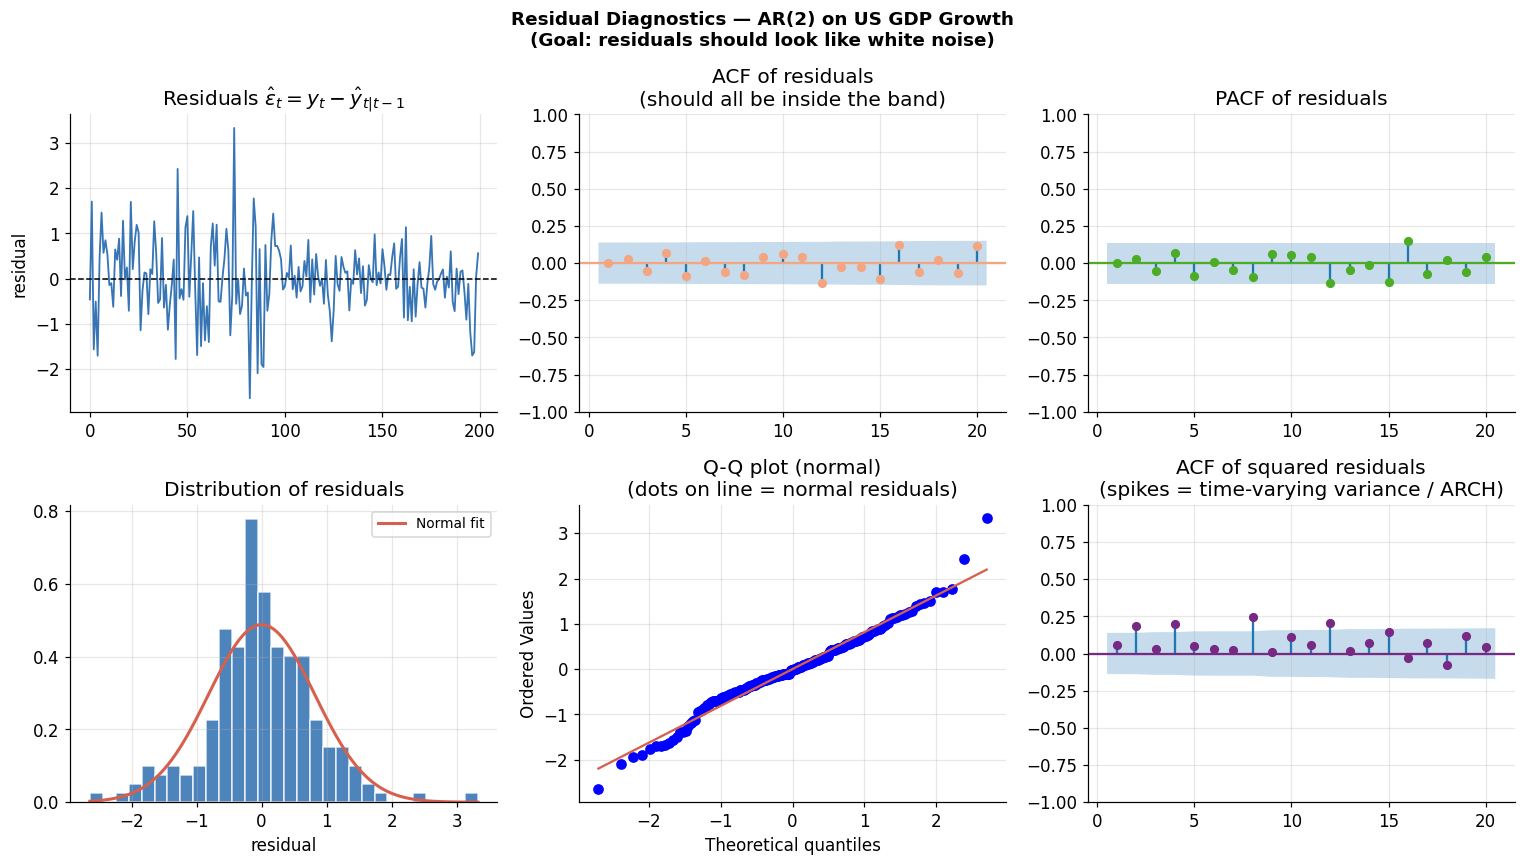

In [20]:
# ── Residual diagnostics for AR(2) on GDP growth ─────────────────────────────
from statsmodels.stats.stattools import jarque_bera

gdp = macro['gdp_growth'].dropna()
fit = AutoReg(gdp, lags=2, old_names=False).fit()
resid = fit.resid.dropna()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Residual Diagnostics — AR(2) on US GDP Growth\n"
             "(Goal: residuals should look like white noise)", fontsize=12, fontweight='bold')

# 1. Residual time series
axes[0,0].plot(resid.values, color=BLUE, lw=1.2, alpha=0.9)
axes[0,0].axhline(0, color='black', lw=1, ls='--')
axes[0,0].set_title(r"Residuals $\hat\varepsilon_t = y_t - \hat y_{t|t-1}$")
axes[0,0].set_ylabel("residual")

# 2. ACF of residuals
plot_acf(resid, ax=axes[0,1], lags=20, color=ORANGE, zero=False)
axes[0,1].set_title("ACF of residuals\n(should all be inside the band)")

# 3. PACF of residuals
plot_pacf(resid, ax=axes[0,2], lags=20, method='ywm', color=GREEN, zero=False)
axes[0,2].set_title("PACF of residuals")

# 4. Histogram + normal fit
from scipy import stats as scipy_stats
axes[1,0].hist(resid, bins=30, color=BLUE, edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(resid.min(), resid.max(), 100)
axes[1,0].plot(xr, scipy_stats.norm.pdf(xr, resid.mean(), resid.std()),
               color=RED, lw=2, label='Normal fit')
axes[1,0].set_title("Distribution of residuals")
axes[1,0].set_xlabel("residual")
axes[1,0].legend(fontsize=9)

# 5. QQ plot
scipy_stats.probplot(resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q plot (normal)\n(dots on line = normal residuals)")
axes[1,1].get_lines()[1].set_color(RED)

# 6. Squared residuals ACF (ARCH check)
plot_acf(resid**2, ax=axes[1,2], lags=20, color=PURPLE, zero=False)
axes[1,2].set_title("ACF of squared residuals\n(spikes = time-varying variance / ARCH)")

plt.tight_layout()
plt.show()

In [21]:
# ── Formal tests ─────────────────────────────────────────────────────────────

print("=" * 58)
print("Diagnostic Tests — AR(2) on US GDP Growth")
print("=" * 58)

# Ljung-Box
lb = acorr_ljungbox(resid, lags=[4, 8, 12, 16], return_df=True)
print("\n1. Ljung-Box Test  (H0: no autocorrelation in residuals)")
print(lb[['lb_stat','lb_pvalue']].rename(
    columns={'lb_stat':'Q*', 'lb_pvalue':'p-value'}).round(4))
any_sig = (lb['lb_pvalue'] < 0.05).any()
print(f"   Conclusion: {'Residuals have autocorrelation -> increase p' if any_sig else 'No significant autocorrelation -> model OK'}")

# Jarque-Bera
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print(f"\n2. Jarque-Bera Test  (H0: residuals are normally distributed)")
print(f"   JB = {jb_stat:.3f},  p-value = {jb_p:.4f},  skew = {skew:.3f},  excess kurtosis = {kurt:.3f}")
print(f"   Conclusion: {'Reject normality (fat tails / skewness)' if jb_p < 0.05 else 'Cannot reject normality'}")

# ARCH-LM test
from statsmodels.stats.diagnostic import het_arch
arch_stat, arch_p, _, _ = het_arch(resid, nlags=4)
print(f"\n3. ARCH-LM Test  (H0: no conditional heteroscedasticity)")
print(f"   ARCH-LM(4) = {arch_stat:.3f},  p-value = {arch_p:.4f}")
print(f"   Conclusion: {'Time-varying variance detected' if arch_p < 0.05 else 'No evidence of ARCH effects'}")

print("\n" + "=" * 58)
print("Now compare with SP500 returns (expect very different results):")
print("=" * 58)
sp_fit   = AutoReg(sp500['ret_pct'].dropna(), lags=1, old_names=False).fit()
sp_resid = sp_fit.resid.dropna()
arch_stat2, arch_p2, _, _ = het_arch(sp_resid, nlags=4)
lb2 = acorr_ljungbox(sp_resid**2, lags=[4], return_df=True)
print(f"\nSP500 AR(1) residuals:")
print(f"  ARCH-LM(4): stat={arch_stat2:.2f}, p={arch_p2:.4f}  <- {'ARCH effects present!' if arch_p2 < 0.05 else 'OK'}")
print(f"  LB on squared resid: p={lb2['lb_pvalue'].iloc[0]:.4f}  <- {'Volatility clustering!' if lb2['lb_pvalue'].iloc[0] < 0.05 else 'OK'}")
print("\n(Financial returns typically show ARCH effects -> variance is not constant across time)")

Diagnostic Tests — AR(2) on US GDP Growth

1. Ljung-Box Test  (H0: no autocorrelation in residuals)
         Q*  p-value
4    1.6036   0.8081
8    5.2109   0.7348
12  10.6259   0.5612
16  16.4800   0.4200
   Conclusion: No significant autocorrelation -> model OK

2. Jarque-Bera Test  (H0: residuals are normally distributed)
   JB = 20.958,  p-value = 0.0000,  skew = 0.085,  excess kurtosis = 4.577
   Conclusion: Reject normality (fat tails / skewness)

3. ARCH-LM Test  (H0: no conditional heteroscedasticity)
   ARCH-LM(4) = 13.351,  p-value = 0.0097
   Conclusion: Time-varying variance detected

Now compare with SP500 returns (expect very different results):

SP500 AR(1) residuals:
  ARCH-LM(4): stat=106.36, p=0.0000  <- ARCH effects present!
  LB on squared resid: p=0.0000  <- Volatility clustering!

(Financial returns typically show ARCH effects -> variance is not constant across time)


---
## Step 8 — Recursive Out-of-Sample Forecasting & Evaluation

This is the step that connects everything to the **seminar's empirical requirements**. We produce the full sequence of recursive forecasts for $h = \{1, 2, 3, 4\}$, using both direct and iterative methods, and evaluate with MAE and RMSE.

**The procedure** (seminar slides 13–14):

1. Fix the initial estimation window ending at $\tau_0$ (require $\geq 40$ observations)
2. For each $t = \tau_0, \tau_0+1, \ldots, T-h$:
   - Estimate AR($p$) on data $[1, t]$
   - Produce $\hat{y}_{t+h|t}$ (direct or iterative)
   - Record the forecast error $e_{t+h} = y_{t+h} - \hat{y}_{t+h|t}$
3. Compute $\text{MAE}_h$ and $\text{RMSE}_h$ across all forecast errors

**Two series, two methods** — so we can see when the AR(p) model struggles vs. when it performs well.


In [22]:
# ── Recursive forecasting engine: both direct and iterative ──────────────────

def recursive_ar_forecast(series, p, h, min_obs=40, method='iterative'):
    # Recursive h-step AR(p) forecast.
    y = series.dropna()
    T = len(y)
    dates, acts, fcs = [], [], []

    for t in range(min_obs - 1, T - h):
        y_train = y.iloc[:t+1]

        if method == 'iterative':
            # Estimate once, chain forward
            fit = AutoReg(y_train, lags=p, old_names=False).fit()
            fc  = fit.forecast(steps=h).iloc[-1]

        else:  # direct
            # Re-estimate for this specific horizon h
            # Regress y[t+h] on [1, y[t], ..., y[t-p+1]] across all t in training
            yv = y_train.values
            N  = len(yv)
            if N < p + h + 5:
                continue
            Y_d = yv[p + h - 1:]
            X_d = np.column_stack(
                [np.ones(len(Y_d))] +
                [yv[p + h - 1 - j: len(yv) - j] for j in range(p)])
            try:
                beta = np.linalg.solve(X_d.T @ X_d, X_d.T @ Y_d)
                x_last = np.array([1] + [yv[-(j+1)] for j in range(p)])
                fc = float(x_last @ beta)
            except np.linalg.LinAlgError:
                continue

        dates.append(y.index[t + h])
        acts.append(y.iloc[t + h])
        fcs.append(fc)

    df = pd.DataFrame({'actual': acts, 'forecast': fcs}, index=dates)
    df['error'] = df['actual'] - df['forecast']
    return df

print("Running recursive forecasts (this may take a few seconds)...")
gdp  = macro['gdp_growth'].dropna()
tinv = macro['inv_growth'].dropna()

results = {}
for ser_name, ser in [('GDP growth', gdp), ('Investment growth', tinv)]:
    for method in ['iterative', 'direct']:
        for h in [1, 2, 3, 4]:
            key = (ser_name, method, h)
            results[key] = recursive_ar_forecast(ser, p=2, h=h, method=method)

print("Done.")
print(f"GDP growth OOS period: {results[('GDP growth','iterative',1)].index[0]}"
      f" -> {results[('GDP growth','iterative',1)].index[-1]}")

Running recursive forecasts (this may take a few seconds)...


Done.
GDP growth OOS period: 1969Q2 -> 2009Q3


In [23]:
# ── RMSE and MAE table: the seminar's core output ────────────────────────────

def mae(e):  return np.mean(np.abs(e))
def rmse(e): return np.sqrt(np.mean(e**2))

for ser_name in ['GDP growth', 'Investment growth']:
    print(f"\n{'='*60}")
    print(f"Series: US {ser_name}")
    print(f"{'Method':<12} {'h=1 RMSE':>10} {'h=2 RMSE':>10} {'h=3 RMSE':>10} {'h=4 RMSE':>10}")
    print("─" * 52)
    for method in ['iterative', 'direct']:
        row = f"{method:<12}"
        for h in [1, 2, 3, 4]:
            r = results[(ser_name, method, h)]
            row += f"  {rmse(r['error']):>8.4f}"
        print(row)
    print(f"\n{'Method':<12} {'h=1 MAE':>10} {'h=2 MAE':>10} {'h=3 MAE':>10} {'h=4 MAE':>10}")
    print("─" * 52)
    for method in ['iterative', 'direct']:
        row = f"{method:<12}"
        for h in [1, 2, 3, 4]:
            r = results[(ser_name, method, h)]
            row += f"  {mae(r['error']):>8.4f}"
        print(row)


Series: US GDP growth
Method         h=1 RMSE   h=2 RMSE   h=3 RMSE   h=4 RMSE
────────────────────────────────────────────────────
iterative       0.8311    0.8639    0.8869    0.8854
direct          1.0065    1.0582    1.1456    1.1450

Method          h=1 MAE    h=2 MAE    h=3 MAE    h=4 MAE
────────────────────────────────────────────────────
iterative       0.6049    0.6217    0.6374    0.6317
direct          0.7427    0.7578    0.8726    0.8508

Series: US Investment growth
Method         h=1 RMSE   h=2 RMSE   h=3 RMSE   h=4 RMSE
────────────────────────────────────────────────────
iterative       4.6375    4.6968    4.6814    4.6742
direct          5.7218    6.2255    5.9818    6.3588

Method          h=1 MAE    h=2 MAE    h=3 MAE    h=4 MAE
────────────────────────────────────────────────────
iterative       3.4010    3.4323    3.4083    3.3919
direct          4.2366    4.5782    4.4692    4.6062


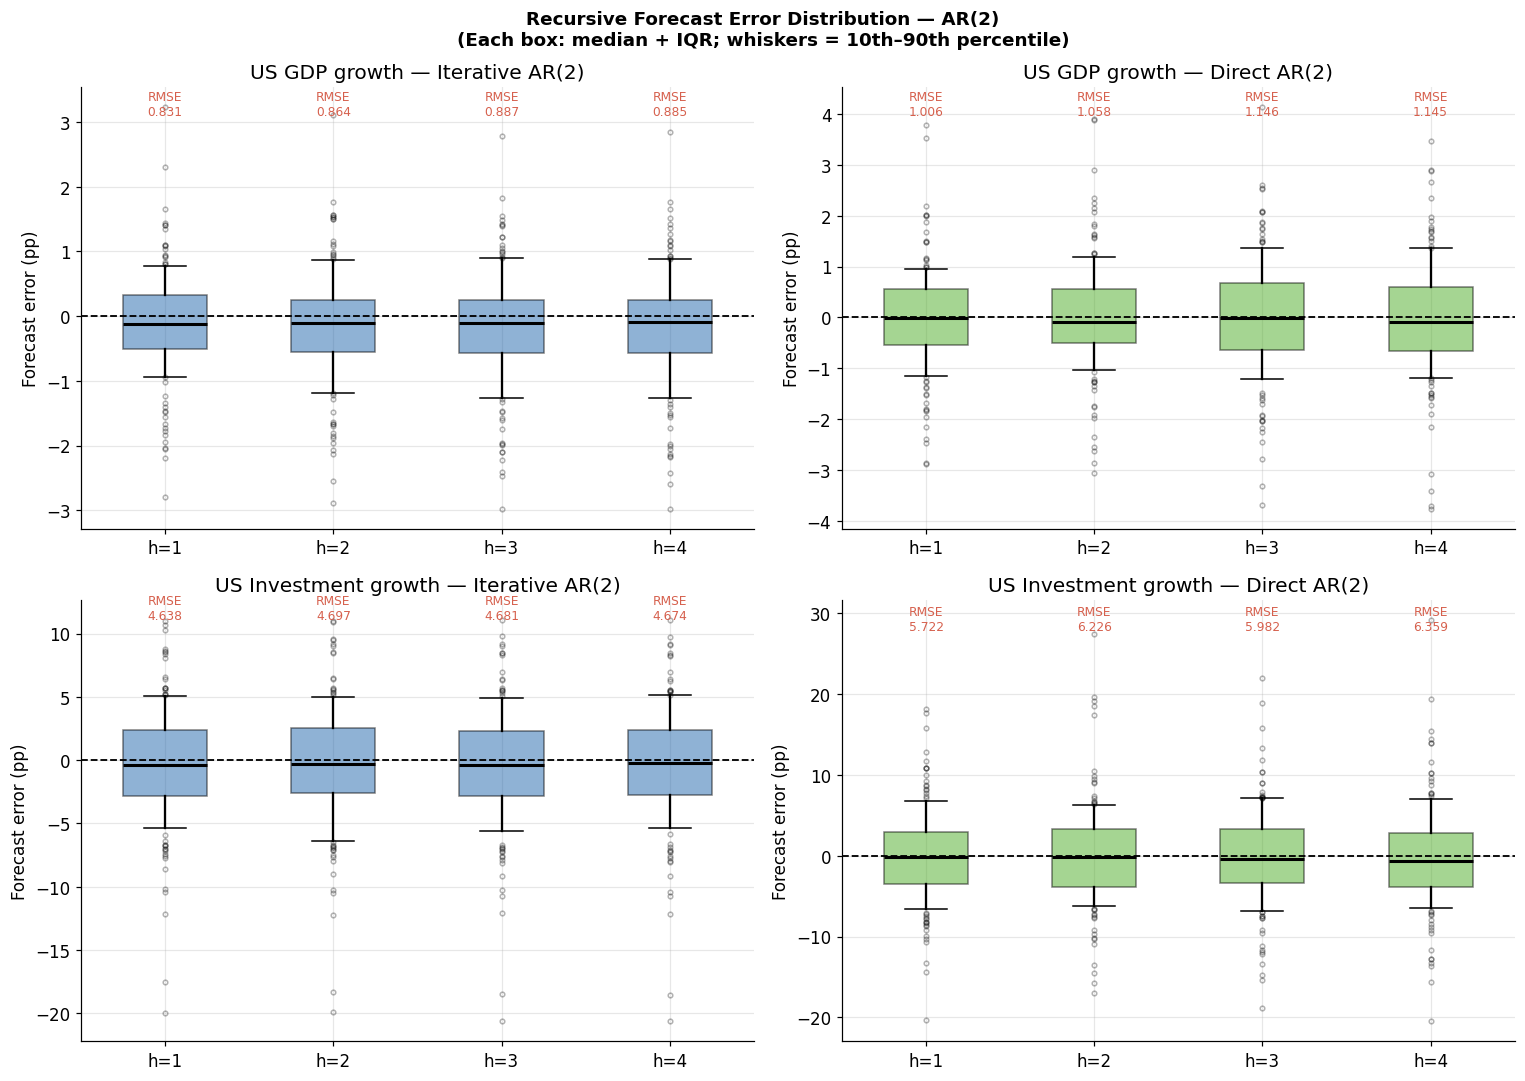

In [24]:
# ── Whisker plot: seminar format ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Recursive Forecast Error Distribution — AR(2)\n"
             "(Each box: median + IQR; whiskers = 10th–90th percentile)",
             fontsize=12, fontweight='bold')

for row_idx, ser_name in enumerate(['GDP growth', 'Investment growth']):
    for col_idx, method in enumerate(['iterative', 'direct']):
        ax = axes[row_idx, col_idx]
        error_data = [results[(ser_name, method, h)]['error'].values
                      for h in [1, 2, 3, 4]]

        bp = ax.boxplot(error_data, positions=[1, 2, 3, 4], widths=0.5,
                        patch_artist=True,
                        boxprops=dict(facecolor=BLUE if method=='iterative' else GREEN,
                                      alpha=0.5),
                        medianprops=dict(color='black', lw=2),
                        whiskerprops=dict(lw=1.5),
                        flierprops=dict(marker='o', ms=3, alpha=0.3),
                        whis=[10, 90])
        ax.axhline(0, color='black', lw=1.2, ls='--')
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(['h=1', 'h=2', 'h=3', 'h=4'])
        ax.set_title(f"US {ser_name} — {method.capitalize()} AR(2)")
        ax.set_ylabel("Forecast error (pp)")

        # Annotate RMSE
        for h in [1, 2, 3, 4]:
            r_h = rmse(results[(ser_name, method, h)]['error'])
            ax.annotate(f"RMSE\n{r_h:.3f}", xy=(h, ax.get_ylim()[1]*0.88),
                        ha='center', fontsize=8, color=RED)

plt.tight_layout()
plt.show()

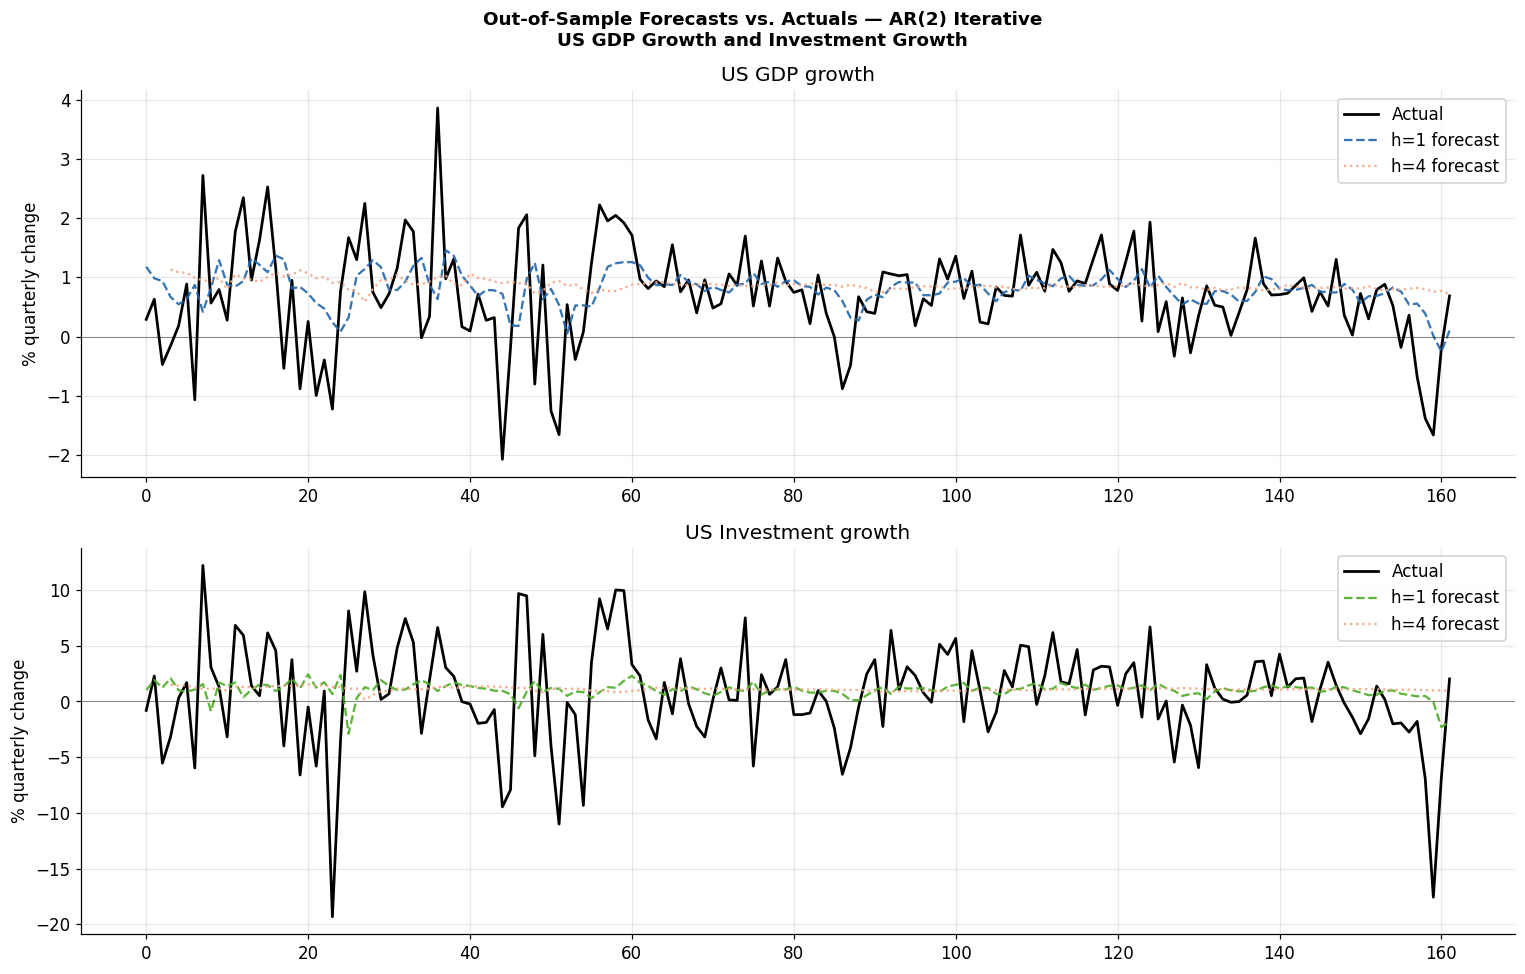

Key observations:
  1. h=1 forecasts track actuals reasonably well in normal times
  2. h=4 forecasts converge toward the unconditional mean quickly
  3. Both models badly miss the 2008-2009 crisis -> extreme events are not forecastable
  4. Investment growth is much more volatile -> larger forecast errors


In [25]:
# ── Forecast paths: actuals vs. recursive forecasts over time ────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Out-of-Sample Forecasts vs. Actuals — AR(2) Iterative\n"
             "US GDP Growth and Investment Growth", fontsize=12, fontweight='bold')

for ax, ser_name, color in zip(axes,
                               ['GDP growth', 'Investment growth'],
                               [BLUE, GREEN]):
    r1 = results[(ser_name, 'iterative', 1)]
    r4 = results[(ser_name, 'iterative', 4)]

    ax.plot(range(len(r1)), r1['actual'].values,   color='black',  lw=1.8, label='Actual')
    ax.plot(range(len(r1)), r1['forecast'].values, color=color,    lw=1.5, ls='--', alpha=0.9, label='h=1 forecast')
    # h=4 has fewer obs, align to end
    r4_vals = r4['forecast'].values
    ax.plot(range(len(r1)-len(r4_vals), len(r1)), r4_vals, color=ORANGE, lw=1.5, ls=':', alpha=0.9, label='h=4 forecast')
    ax.axhline(0, color='black', lw=0.7, alpha=0.4)
    ax.set_title(f"US {ser_name}")
    ax.set_ylabel("% quarterly change")
    ax.legend(framealpha=0.9)

    ax.set_ylabel('% quarterly change')

plt.tight_layout()
plt.show()

print("Key observations:")
print("  1. h=1 forecasts track actuals reasonably well in normal times")
print("  2. h=4 forecasts converge toward the unconditional mean quickly")
print("  3. Both models badly miss the 2008-2009 crisis -> extreme events are not forecastable")
print("  4. Investment growth is much more volatile -> larger forecast errors")

---
## Summary — AR(p) Checklist and Key Takeaways

### The AR(p) pipeline in 8 steps

| Step | Action | Key formula / tool |
|------|--------|--------------------|
| 1 | Write down the model | $y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$ |
| 2 | Check stationarity | ADF test; roots of $\phi(\lambda)=0$ outside unit circle |
| 3 | Choose lag $p$ | PACF cuts off at $p$; minimize AIC or BIC |
| 4 | Estimate | OLS: $\hat{\boldsymbol\phi} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ |
| 5 | 1-step forecast | $\hat{y}_{T+1\mid T} = c + \hat\phi_1 y_T + \cdots + \hat\phi_p y_{T-p+1}$ |
| 6 | h-step forecast | Direct (re-estimate each $h$) or Iterative (chain 1-step) |
| 7 | Diagnose residuals | Ljung-Box, Jarque-Bera, ARCH-LM |
| 8 | Evaluate OOS | Recursive scheme → MAE, RMSE, whisker plots |

### What we learned from the data

| Series | AR order | Key finding |
|--------|----------|-------------|
| US GDP growth | AR(2) | Moderate persistence ($\phi_1 \approx 0.3$); residuals roughly OK |
| US Investment growth | AR(2) | High volatility; RMSE much larger than GDP |
| SP500 daily returns | AR(1) | Near-zero $\phi_1$; returns nearly unpredictable; strong ARCH effects |
| Canadian T-bill rate | AR(2) | High persistence ($\phi_1 \approx 0.9$); close to unit root |

### Role of AR(p) in the seminar
The AR(p) is your **benchmark model** — every more complex model (M2, M3, random forest) must beat it to be worth using. If your dynamic regression or bridge equation cannot improve on AR(p) RMSE, the extra complexity is not justified.

---
*Next notebook → Module 2: Dynamic Linear Regression (M2) — adding exogenous variables*
